# California House Price Prediction Using Linear Regression

## Artificial Intelligence & Machine Learning – Task 1

### Objective

The objective of this project is to build and evaluate a Linear Regression model for predicting house prices using the California Housing dataset.

### Machine Learning Workflow

1. Data Loading
2. Data Exploration
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Train-Test Split
6. Model Training
7. Prediction
8. Model Evaluation
9. Visualization
10. Conclusion

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("Project libraries imported successfully!")

Project libraries imported successfully!


In [44]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [45]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [46]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (20640, 9)


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [48]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [49]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [50]:
print("Number of rows and columns:", df.shape)
df.info()
df.isnull().sum()
df.describe()

Number of rows and columns: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


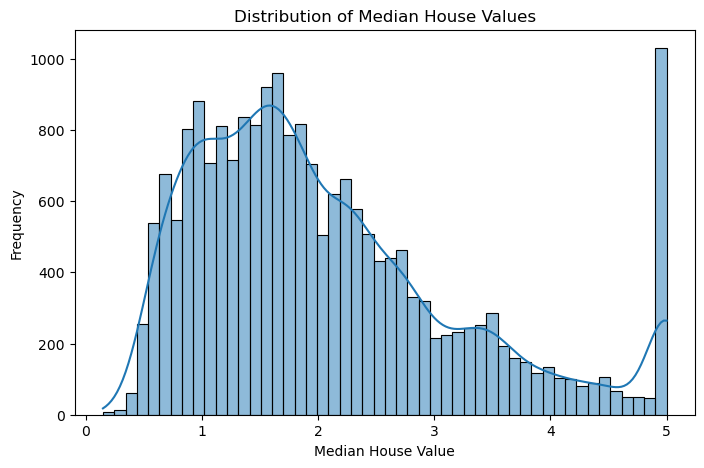

In [51]:
plt.figure(figsize=(8, 5))

sns.histplot(df["MedHouseVal"], bins=50, kde=True)

plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

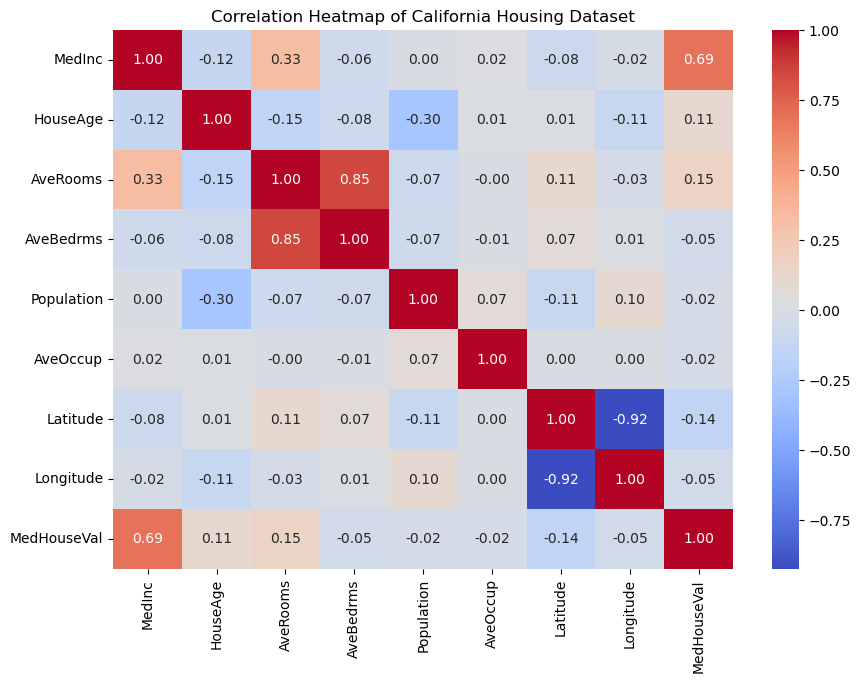

In [52]:
plt.figure(figsize=(10, 7))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of California Housing Dataset")
plt.show()

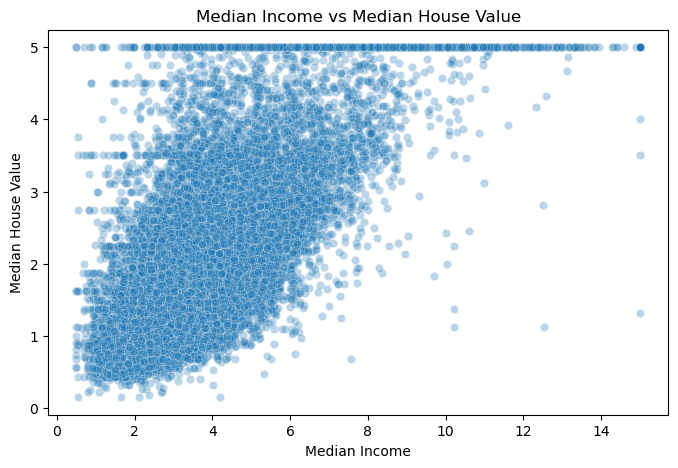

In [53]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.3
)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

### EDA Observation

The correlation heatmap shows that MedInc has the strongest positive correlation with MedHouseVal, with a correlation coefficient of approximately 0.69. This indicates that median income is an important feature associated with house prices in the dataset.

The scatter plot between MedInc and MedHouseVal also helps visualize this positive relationship.

In [54]:
# Separate features and target

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [57]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [58]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 5 predictions:")
print(y_pred[:5])

Predictions generated successfully!
First 5 predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
-------------------------
MAE : 0.5332001304956566
RMSE: 0.7455813830127763
R²  : 0.5757877060324508


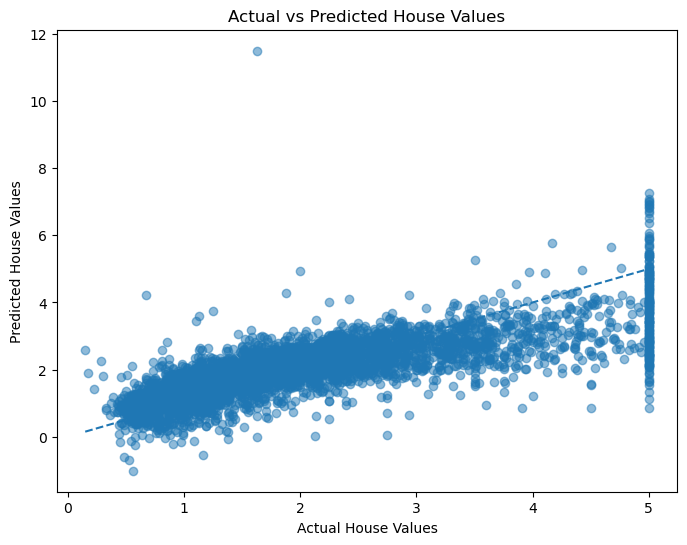

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")

plt.show()

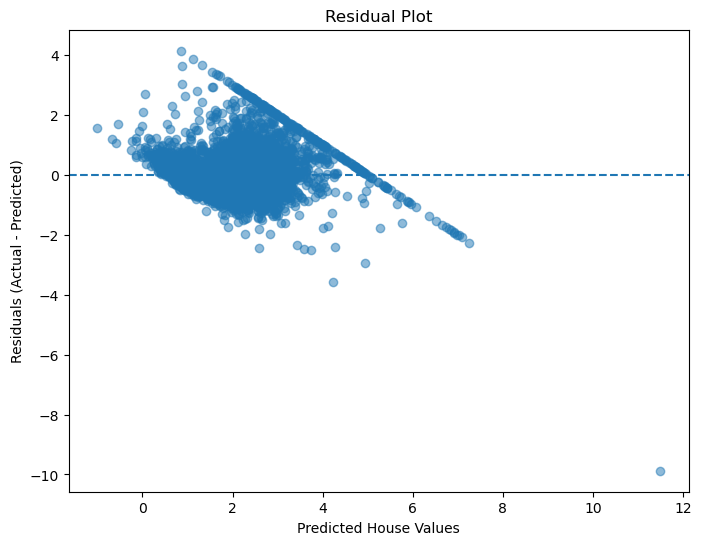

In [61]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted House Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

## Model Interpretation

The Linear Regression model was evaluated using MAE, RMSE, and R².

- MAE = 0.5332
- RMSE = 0.7456
- R² = 0.5758

The R² score of approximately 0.576 indicates that the model explains about 57.6% of the variation in median house values.

The positive relationship between Median Income (MedInc) and Median House Value (MedHouseVal) was also observed during Exploratory Data Analysis.

The residual plot shows that the prediction errors are not completely random and that some variation remains unexplained by the linear model.

## Conclusion

In this project, a Linear Regression model was developed to predict median house values using the California Housing dataset.

The project included data loading, data exploration, statistical analysis, visualization, correlation analysis, feature scaling, model training, prediction, and model evaluation.

The model achieved an R² score of approximately 0.576, with an MAE of 0.5332 and RMSE of 0.7456.

The results show that Linear Regression can capture a significant relationship between the selected features and house prices, although some prediction error remains. More advanced machine learning models could potentially improve the prediction performance.